# CS 790 — Final evaluation notebook
**Complete pipeline: quality check → downstream classifier → ablation**

**Part 1:** Quality check on 180×180 outputs (FID + visual + classifier sanity)
**Part 2:** Downstream evaluation — retrain ResNet with synthetic data
**Part 3:** Ablation — vary synthetic ratio, compare CycleGAN vs Diffusion

All results auto-save to Drive after each run. Safe against Colab disconnects.

In [1]:
# ════════════════════════════════════════════════
# Cell 1: Setup
# ════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')
!pip install -q pytorch-fid scikit-learn

import os, gc, json, time, warnings, shutil, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
Device: cuda
  GPU: Tesla T4


In [3]:
# ════════════════════════════════════════════════
# Cell 2: Paths + extract images
# ════════════════════════════════════════════════
PROJECT_DIR = "/content/drive/MyDrive/2-Education/0-BU_MSADA/Classes/3-Spring_2026/790_CV/CV-Project/deliverables/4- Code Files"
SPLITS_DIR = os.path.join(PROJECT_DIR, "data/splits")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
IMAGES_DIR = "/content/finger_joints"

# CycleGAN
CYCLE_DIR = os.path.join(MODELS_DIR, "cyclegan_outputs")
CYCLE_MANIFEST = os.path.join(CYCLE_DIR, "synthetic_manifest.csv")
CYCLE_IMAGES = os.path.join(CYCLE_DIR, "images")
CYCLE_BY_KL = os.path.join(CYCLE_DIR, "images_by_kl")

# Diffusion 180×180
DIFF_DIR = os.path.join(MODELS_DIR, "diffusion_outputs")
DIFF_MANIFEST_180 = os.path.join(DIFF_DIR, "synthetic_manifest_180.csv")
DIFF_IMAGES_180 = os.path.join(DIFF_DIR, "images_180")
DIFF_BY_KL_180 = os.path.join(DIFF_DIR, "images_by_kl_180")

# Results
RESULTS_DIR = os.path.join(MODELS_DIR, "eval_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Extract real images
import zipfile
ZIP_PATH = os.path.join(PROJECT_DIR, "data/raw/Finger_Joints.zip")
if not os.path.exists(IMAGES_DIR) or len(os.listdir(IMAGES_DIR)) < 100:
    print("Extracting zip...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(IMAGES_DIR)
    print("Done")

img_root = IMAGES_DIR
for root, dirs, files in os.walk(IMAGES_DIR):
    if len([f for f in files if f.endswith('.png')]) > 1000:
        img_root = root
        break
print(f"Image root: {img_root}")

Extracting zip...
Done
Image root: /content/finger_joints/Finger Joints


In [4]:
# ════════════════════════════════════════════════
# Cell 3: Load all manifests
# ════════════════════════════════════════════════


# Real
real_df = pd.read_csv(os.path.join(SPLITS_DIR, "manifest_dip_only.csv"))
if 'v00_KL' in real_df.columns:
    real_df = real_df.rename(columns={'v00_KL':'KL','v00_JSN':'JSN','v00_OP':'OP','v00_ER':'ER'})
if 'image_path' in real_df.columns and 'filename' not in real_df.columns:
    real_df['filename'] = real_df['image_path'].apply(os.path.basename)
if 'val' in real_df['split'].values:
    real_df['split'] = real_df['split'].replace({'val':'validation'})

real_df = real_df[real_df.KL.notna()].copy()
real_df['KL'] = real_df['KL'].astype(int)

# Verify path
test_path = os.path.join(img_root, real_df['filename'].iloc[0])
if not os.path.exists(test_path):
    alt = os.path.join(IMAGES_DIR, "Finger Joints")
    if os.path.exists(os.path.join(alt, real_df['filename'].iloc[0])):
        img_root = alt

# CycleGAN
cycle_df = pd.read_csv(CYCLE_MANIFEST) if os.path.exists(CYCLE_MANIFEST) else None
if cycle_df is not None:
    # Ensure KL is integer (Jai maps '2+' to 2, '0-1' to 0)
    cycle_df['KL'] = pd.to_numeric(cycle_df['KL'], errors='coerce').fillna(2).astype(int)
    cycle_df['binary_label'] = (cycle_df['KL'] >= 2).astype(int)

# Diffusion 180
diff_df = None
if os.path.exists(DIFF_MANIFEST_180):
    diff_df = pd.read_csv(DIFF_MANIFEST_180)
else:
    # Try alternate manifest name
    alt_manifest = os.path.join(DIFF_DIR, "synthetic_manifest.csv")
    if os.path.exists(alt_manifest):
        diff_df = pd.read_csv(alt_manifest)
        print(f"  Using fallback manifest: {alt_manifest}")

print(f"Real: {len(real_df):,} images, {real_df.patient_id.nunique()} patients")
print(f"  Train: {len(real_df[real_df.split=='train']):,}")
print(f"  KL distribution: {dict(real_df[real_df.split=='train'].KL.value_counts().sort_index())}")

if cycle_df is not None:
    print(f"\nCycleGAN: {len(cycle_df)} images")
    print(f"  Per grade: {dict(cycle_df.KL.value_counts().sort_index())}")

if diff_df is not None:
    print(f"\nDiffusion 180: {len(diff_df)} images")
    print(f"  Per grade: {dict(diff_df.KL.value_counts().sort_index())}")

# Constants
SEEDS = [42, 123, 456]
IMG_SIZE = 180
MEAN = [0.2339] * 3
STD = [0.2349] * 3
BATCH_SIZE = 32

Real: 13,171 images, 3505 patients
  Train: 9,199
  KL distribution: {0: np.int64(5947), 1: np.int64(1220), 2: np.int64(1770), 3: np.int64(144), 4: np.int64(118)}

CycleGAN: 600 images
  Per grade: {0: np.int64(300), 2: np.int64(300)}

Diffusion 180: 1500 images
  Per grade: {0: np.int64(300), 1: np.int64(300), 2: np.int64(300), 3: np.int64(300), 4: np.int64(300)}


In [5]:
# ════════════════════════════════════════════════
# Cell 4: Dataset, model, training functions (shared by all experiments)
# ════════════════════════════════════════════════

class OADataset(Dataset):
    def __init__(self, manifest_df, img_dir, transform=None, binary=False):
        self.df = manifest_df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.binary = binary

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        if not os.path.exists(img_path) and 'image_path' in row:
            img_path = row['image_path']
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = int(row['KL'])
        if self.binary:
            label = 0 if label <= 1 else 1
        return img, label

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def build_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, num_classes):
    model.eval()
    total_loss = 0
    all_labels, all_probs = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        total_loss += criterion(outputs, labels).item() * images.size(0)
        all_labels.append(labels.cpu())
        all_probs.append(torch.softmax(outputs, dim=1).cpu())
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()
    if num_classes == 2:
        auc_score = roc_auc_score(all_labels, all_probs[:, 1])
    else:
        try:
            auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except:
            auc_score = 0.0
    return total_loss / len(all_labels), auc_score, all_labels, all_probs

def train_model(train_loader, val_loader, class_weights, num_classes,
                max_epochs=50, patience=10, lr=1e-4, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    model = build_model(num_classes)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    best_auc, best_state, no_improve = 0.0, None, 0
    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        scheduler.step()
        val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, num_classes)
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1:3d} | train_loss={train_loss:.4f} | val_auc={val_auc:.4f} | best={best_auc:.4f}")
        if no_improve >= patience:
            print(f"    Early stop at epoch {epoch+1}")
            break
    model.load_state_dict(best_state)
    model = model.to(device)
    return model, best_auc

def build_loaders(df, img_dir, binary=False, synth_df=None, synth_img_dir=None, synth_ratio=None):
    """Build train/val/test loaders. Optionally add synthetic data to train at given ratio."""
    train_df = df[df.split == 'train'].copy()
    val_df = df[df.split == 'validation'].copy()
    test_df = df[df.split == 'test'].copy()

    # Add synthetic data if provided
    if synth_df is not None and synth_ratio is not None and synth_ratio > 0:
        synth_to_add = pd.DataFrame()
        if binary:
            # For binary: add diseased synthetic (KL 2+)
            synth_diseased = synth_df[synth_df.KL >= 2].copy()
            n_real_diseased = len(train_df[train_df.KL >= 2])
            max_synth = int(n_real_diseased * synth_ratio)
            if len(synth_diseased) > max_synth:
                synth_diseased = synth_diseased.sample(n=max_synth, random_state=42)
            synth_to_add = synth_diseased
        else:
            # For 5-class: add per grade, capped by ratio
            for kl in synth_df.KL.unique():
                grade_synth = synth_df[synth_df.KL == kl].copy()
                n_real = len(train_df[train_df.KL == kl])
                max_synth = int(n_real * synth_ratio)
                if len(grade_synth) > max_synth:
                    grade_synth = grade_synth.sample(n=max_synth, random_state=42)
                synth_to_add = pd.concat([synth_to_add, grade_synth])

        # Ensure synthetic has required columns
        synth_to_add = synth_to_add.copy()
        synth_to_add['split'] = 'train'
        if 'filename' not in synth_to_add.columns and 'image_path' in synth_to_add.columns:
            synth_to_add['filename'] = synth_to_add['image_path'].apply(os.path.basename)

        train_df = pd.concat([train_df, synth_to_add], ignore_index=True)
        print(f"    Added {len(synth_to_add)} synthetic images (ratio={synth_ratio})")

    # Determine num_classes and labels
    if binary:
        num_classes = 2
        train_labels = (train_df.KL.values >= 2).astype(int)
    else:
        num_classes = 5
        train_df = train_df[train_df.KL.notna()].copy()
        train_df['KL'] = train_df['KL'].astype(int)
        train_labels = train_df.KL.values

    # Class weights
    class_counts = np.bincount(train_labels, minlength=num_classes).astype(float)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    class_weights = class_weights / class_weights.sum() * num_classes
    class_weights_tensor = torch.FloatTensor(class_weights).to(device)

    # Sampler
    sample_weights = [class_weights[l] for l in train_labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    # Datasets — need to handle mixed image dirs for synthetic
    # For simplicity: create a combined dataset that checks multiple dirs
    class MultiDirDataset(Dataset):
        def __init__(self, df, img_dirs, transform, binary):
            self.df = df.reset_index(drop=True)
            self.img_dirs = img_dirs if isinstance(img_dirs, list) else [img_dirs]
            self.transform = transform
            self.binary = binary
        def __len__(self):
            return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            fname = row['filename']
            img = None
            for d in self.img_dirs:
                p = os.path.join(d, fname)
                if os.path.exists(p):
                    img = Image.open(p).convert('RGB')
                    break
            if img is None and 'image_path' in row and os.path.exists(str(row.get('image_path',''))):
                img = Image.open(row['image_path']).convert('RGB')
            if img is None:
                img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), 128)
            if self.transform:
                img = self.transform(img)
            label = int(row['KL'])
            if self.binary:
                label = 0 if label <= 1 else 1
            return img, label

    img_dirs = [img_root]
    if synth_img_dir:
        img_dirs.append(synth_img_dir)

    train_ds = MultiDirDataset(train_df, img_dirs, train_transform, binary)
    val_ds = MultiDirDataset(val_df, [img_root], val_transform, binary)
    test_ds = MultiDirDataset(test_df, [img_root], val_transform, binary)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, class_weights_tensor, num_classes

print("✓ All functions defined")

✓ All functions defined


---
# Part 1: Quality check on 180×180 diffusion outputs
Visual + FID + classifier sanity on the new full-resolution outputs.

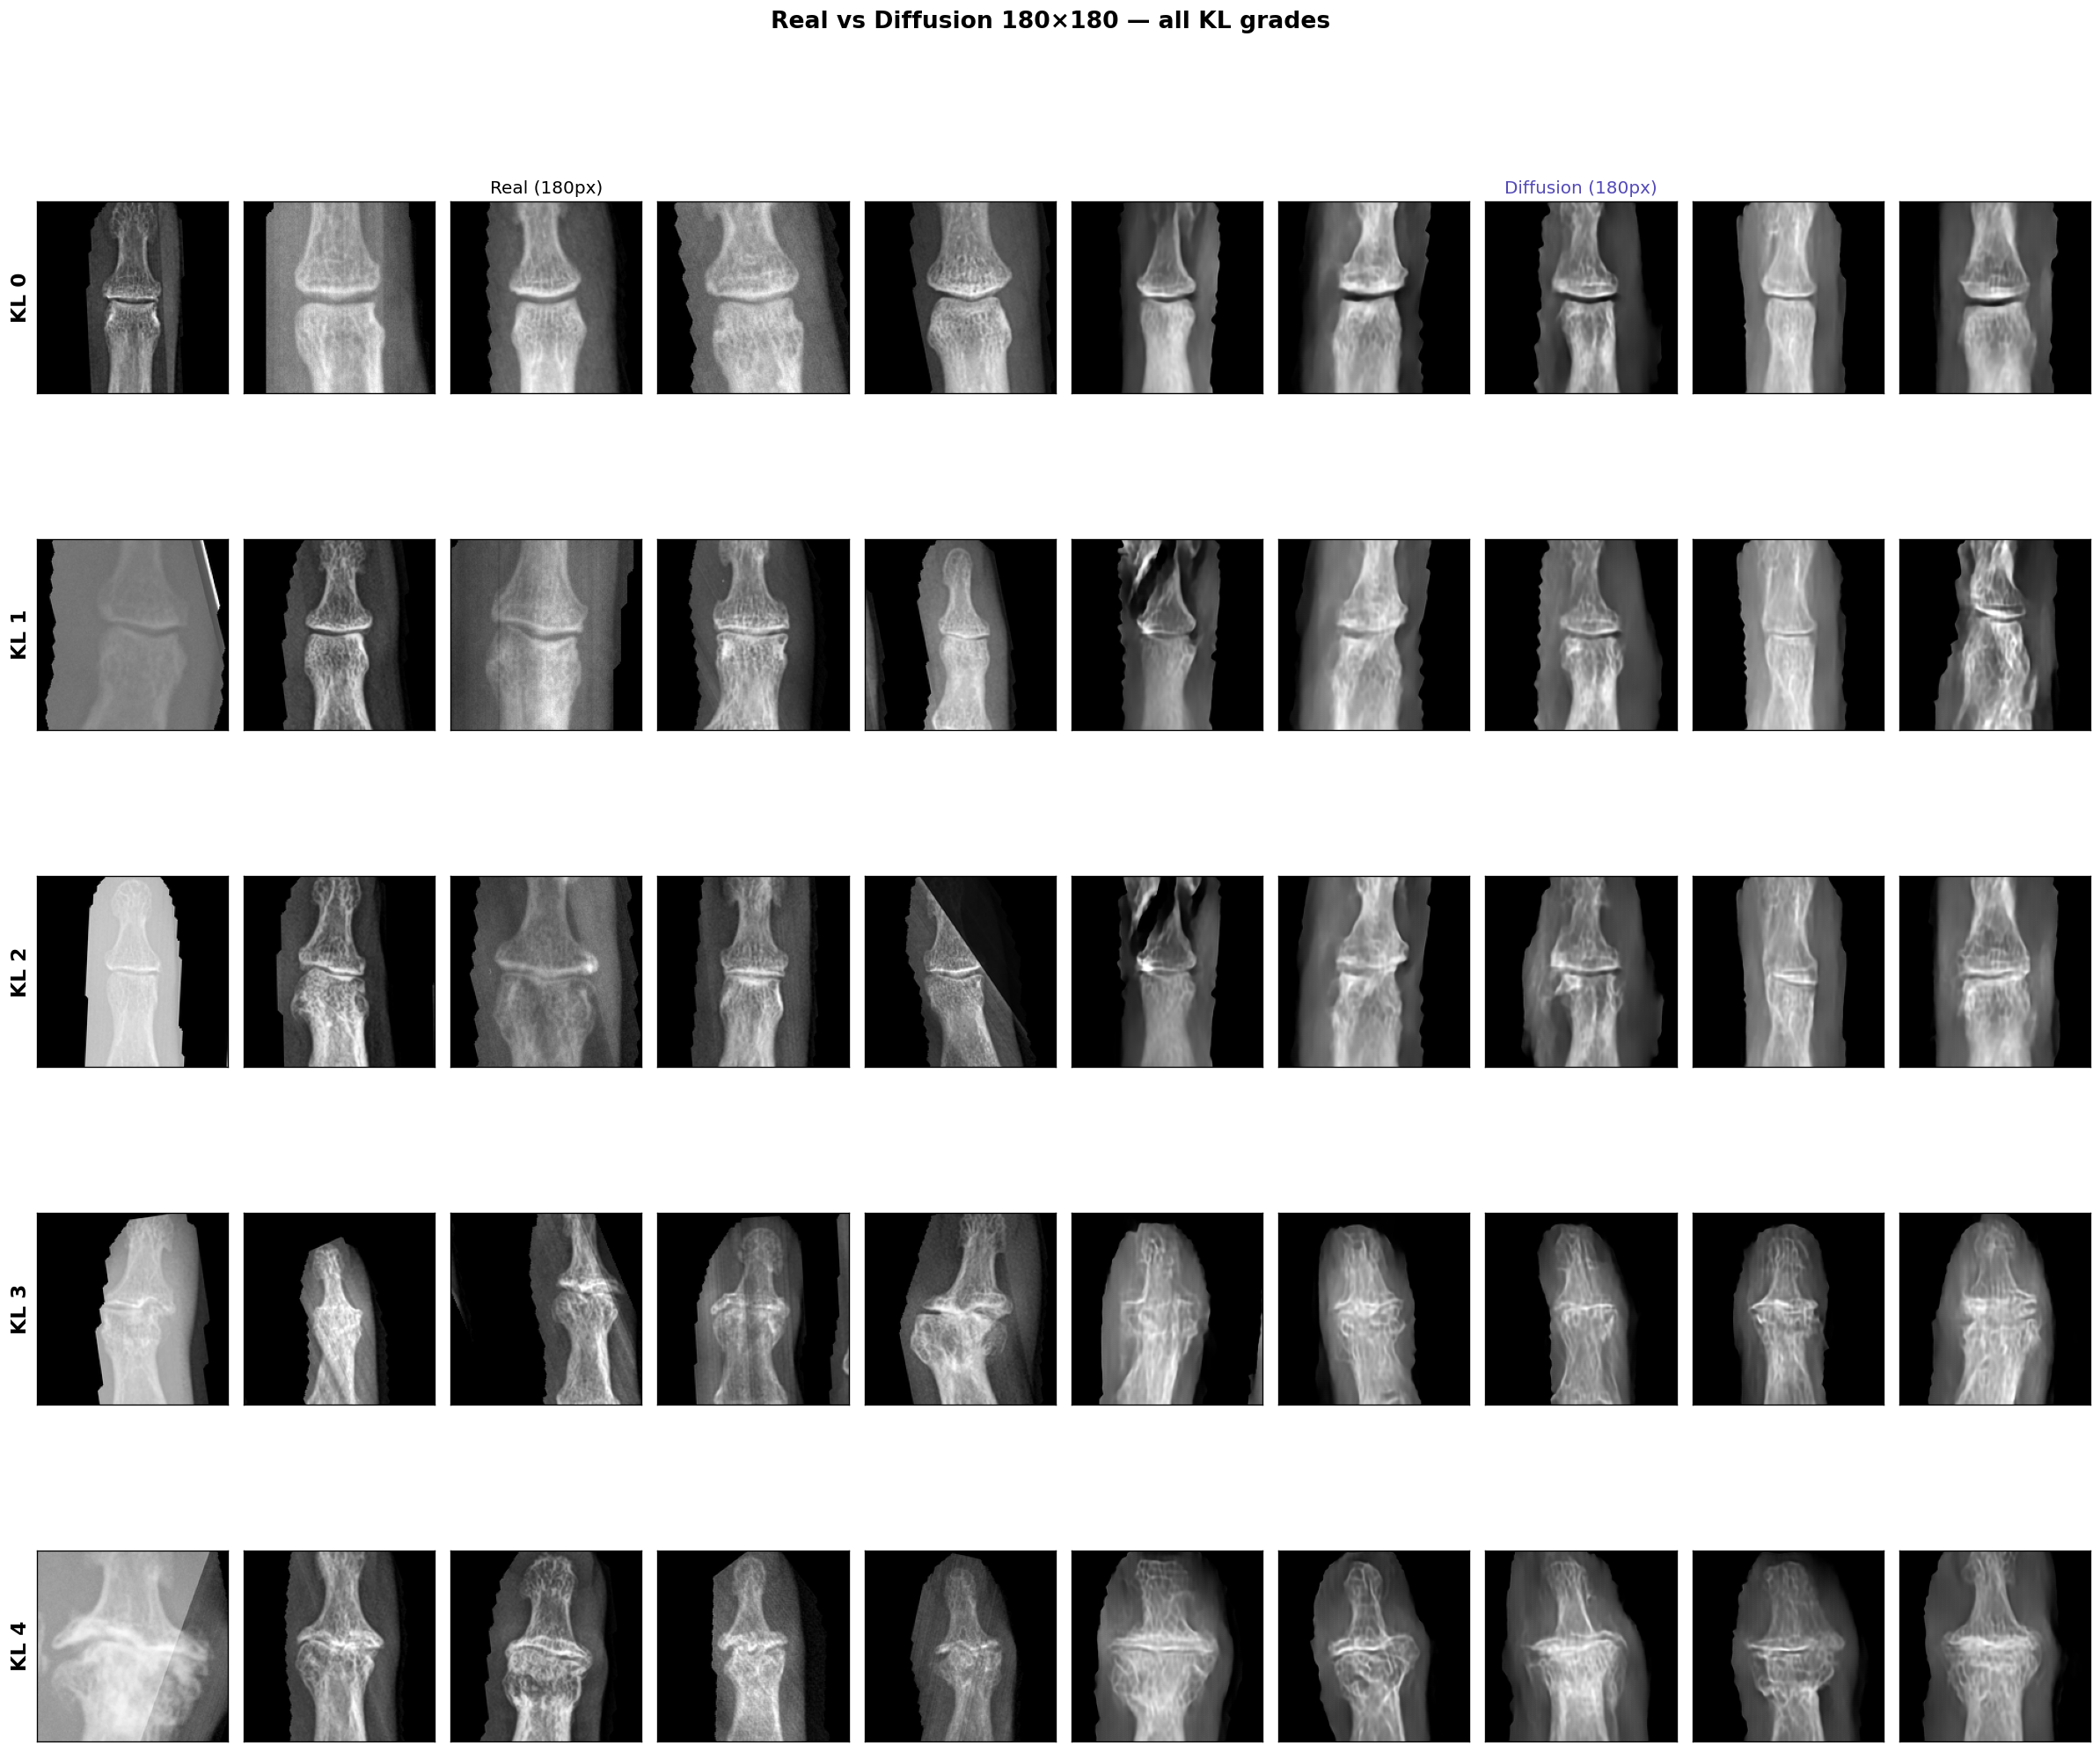

In [ ]:
# ════════════════════════════════════════════════
# Cell 5: Visual comparison — Real vs Diffusion 180 vs CycleGAN
# ════════════════════════════════════════════════

def find_diff_image(row):
    for p in [os.path.join(DIFF_IMAGES_180, row['filename']),
              os.path.join(DIFF_BY_KL_180, f"kl{int(row['KL'])}", row['filename'])]:
        if os.path.exists(p): return p
    return None

n_samples = 5
kl_grades = sorted(diff_df.KL.unique()) if diff_df is not None else [0,1,2,3,4]

fig, axes = plt.subplots(len(kl_grades), n_samples * 2, figsize=(20, 3.5 * len(kl_grades)))

for gi, kl in enumerate(kl_grades):
    # Real
    real_sub = real_df[(real_df.KL == kl) & (real_df.split == 'train')]
    for i, (_, row) in enumerate(real_sub.sample(n=min(n_samples, len(real_sub)), random_state=42).iterrows()):
        ax = axes[gi][i]
        p = os.path.join(img_root, row['filename'])
        if os.path.exists(p): ax.imshow(np.array(Image.open(p)), cmap='gray')
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0: ax.set_ylabel(f'KL {kl}', fontsize=14, fontweight='bold')
        if gi == 0 and i == 2: ax.set_title('Real (180px)', fontsize=12)

    # Diffusion 180
    if diff_df is not None:
        gen_sub = diff_df[diff_df.KL == kl].head(n_samples)
        for i, (_, row) in enumerate(gen_sub.iterrows()):
            ax = axes[gi][n_samples + i]
            p = find_diff_image(row)
            if p: ax.imshow(np.array(Image.open(p)), cmap='gray')
            ax.set_xticks([]); ax.set_yticks([])
            if gi == 0 and i == 2: ax.set_title('Diffusion (180px)', fontsize=12, color='#534AB7')

plt.suptitle('Real vs Diffusion 180×180 — all KL grades', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'visual_diff180.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ════════════════════════════════════════════════
# Cell 6: FID per grade — Diffusion 180×180
# ════════════════════════════════════════════════
from pytorch_fid import fid_score

diff180_fid = {}
print("FID per KL grade — Diffusion 180×180")
print("=" * 50)

for kl in kl_grades:
    gen_folder = os.path.join(DIFF_BY_KL_180, f"kl{int(kl)}")
    if not os.path.exists(gen_folder):
        print(f"  KL {kl}: no folder"); continue
    n_gen = len([f for f in os.listdir(gen_folder) if f.endswith('.png')])
    if n_gen < 10:
        print(f"  KL {kl}: only {n_gen} images"); continue

    real_dir = f"/content/fid_real_{kl}"
    gen_rgb = f"/content/fid_gen_{kl}"
    for d in [real_dir, gen_rgb]:
        if os.path.exists(d): shutil.rmtree(d)
        os.makedirs(d)

    subset = real_df[(real_df.KL == kl) & (real_df.split == 'train')]
    n = min(len(subset), n_gen, 200)
    for _, row in subset.sample(n=n, random_state=42).iterrows():
        src = os.path.join(img_root, row['filename'])
        if os.path.exists(src):
            Image.open(src).convert('RGB').save(os.path.join(real_dir, row['filename']))

    for f in os.listdir(gen_folder):
        if f.endswith('.png'):
            Image.open(os.path.join(gen_folder, f)).convert('RGB').save(os.path.join(gen_rgb, f))

    try:
        fid = fid_score.calculate_fid_given_paths([real_dir, gen_rgb], batch_size=50, device=str(device), dims=2048)
        diff180_fid[int(kl)] = round(fid, 2)
        print(f"  KL {kl}: FID = {fid:.2f}")
    except Exception as e:
        print(f"  KL {kl}: failed — {e}")

    shutil.rmtree(real_dir, ignore_errors=True)
    shutil.rmtree(gen_rgb, ignore_errors=True)

print(f"\nSummary: {diff180_fid}")
with open(os.path.join(RESULTS_DIR, 'fid_diff180.json'), 'w') as f:
    json.dump(diff180_fid, f, indent=2)

FID per KL grade — Diffusion 180×180
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 252MB/s]
100%|██████████| 6/6 [00:01<00:00,  4.19it/s]


  KL 0: FID = 145.53


100%|██████████| 6/6 [00:01<00:00,  4.19it/s]


  KL 1: FID = 145.85


...

  KL 2: FID = 144.91


100%|██████████| 6/6 [00:01<00:00,  4.31it/s]


  KL 3: FID = 139.57


100%|██████████| 6/6 [00:01<00:00,  4.32it/s]


  KL 4: FID = 152.36

Summary: {0: np.float64(145.53), 1: np.float64(145.85), 2: np.float64(144.91), 3: np.float64(139.57), 4: np.float64(152.36)}


---
# Part 2: Downstream evaluation

Retrain ResNet-18 with synthetic data at different ratios.
Compare: baseline vs +CycleGAN vs +Diffusion.

**Ablation ratios:** 0% (baseline), 10%, 25%, 50%, 100%, 200%
**Each config:** 3 seeds × report mean ± std
**Auto-saves after every single run.**

In [7]:
# ════════════════════════════════════════════════
# Cell 7: Run all experiments
#
# Structure:
#   experiment_results[config_name] = [
#       {'seed': 42, 'test_auc': 0.XXX, ...},
#       {'seed': 123, 'test_auc': 0.XXX, ...},
#       {'seed': 456, 'test_auc': 0.XXX, ...},
#   ]
# ════════════════════════════════════════════════

RATIOS = [0.10, 0.25, 0.50, 1.00, 2.00]
SAVE_PATH = os.path.join(RESULTS_DIR, "all_experiment_results.pkl")

# Load existing results if resuming
if os.path.exists(SAVE_PATH):
    experiment_results = pickle.load(open(SAVE_PATH, 'rb'))
    print(f"Loaded existing results: {list(experiment_results.keys())}")
else:
    experiment_results = {}

def run_experiment(config_name, binary, synth_df=None, synth_img_dir=None, ratio=None):
    """Run one experiment config for all seeds. Skips already-completed seeds."""
    if config_name not in experiment_results:
        experiment_results[config_name] = []

    done_seeds = [r['seed'] for r in experiment_results[config_name]]

    for seed in SEEDS:
        if seed in done_seeds:
            print(f"  Seed {seed}: already done, skipping")
            continue

        print(f"  Seed {seed}...")
        gc.collect(); torch.cuda.empty_cache()

        train_loader, val_loader, test_loader, cw, nc = build_loaders(
            real_df, img_root, binary=binary,
            synth_df=synth_df, synth_img_dir=synth_img_dir, synth_ratio=ratio)

        model, best_val = train_model(train_loader, val_loader, cw, nc, seed=seed)
        criterion = nn.CrossEntropyLoss(weight=cw)
        _, test_auc, test_labels, test_probs = evaluate(model, test_loader, criterion, nc)

        # Per-class AUC for 5-class
        per_class = {}
        if not binary:
            for i in range(nc):
                bl = (test_labels == i).astype(int)
                if bl.sum() > 0 and bl.sum() < len(bl):
                    per_class[i] = round(float(roc_auc_score(bl, test_probs[:, i])), 4)

        result = {
            'seed': seed, 'test_auc': round(float(test_auc), 4),
            'per_class_auc': per_class,
            'test_labels': test_labels, 'test_probs': test_probs,
        }
        experiment_results[config_name].append(result)
        print(f"    TEST AUC: {test_auc:.4f}")

        # Save after EVERY run
        pickle.dump(experiment_results, open(SAVE_PATH, 'wb'))

        del model; gc.collect(); torch.cuda.empty_cache()

    # Summary
    aucs = [r['test_auc'] for r in experiment_results[config_name]]
    print(f"  → {config_name}: AUC = {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

print("✓ run_experiment defined")

Loaded existing results: ['baseline_5class', 'baseline_binary', 'cycle_binary_10pct', 'cycle_binary_25pct', 'cycle_binary_50pct', 'cycle_binary_100pct', 'cycle_binary_200pct', 'diff_binary_10pct', 'diff_binary_25pct', 'diff_binary_50pct', 'diff_binary_100pct', 'diff_binary_200pct', 'diff_5class_10pct', 'diff_5class_25pct', 'diff_5class_50pct', 'diff_5class_100pct', 'diff_5class_200pct']
✓ run_experiment defined


In [ ]:
# ════════════════════════════════════════════════
# Cell 8: Load existing baseline results (trained last week)
# ════════════════════════════════════════════════

# The incorrectly indented block that caused the error has been removed.
# The logic for converting `saved` results is correctly handled inside the loop below.

def get_auc(config):
    if config not in experiment_results: return None, None
    aucs = [r['test_auc'] for r in experiment_results[config]]
    return round(np.mean(aucs), 4), round(np.std(aucs), 4)

BASELINE_DIR = os.path.join(MODELS_DIR, "eval_baseline")

for task, config_name in [("5class", "baseline_5class"), ("binary", "baseline_binary")]:
    pkl_path = os.path.join(BASELINE_DIR, f"results_{task}.pkl")
    # Modify condition: load if not in results OR if in results but its list is empty
    if os.path.exists(pkl_path) and (config_name not in experiment_results or not experiment_results[config_name]):
        with open(pkl_path, 'rb') as f:
            saved = pickle.load(f)
        # Convert to our format
        experiment_results[config_name] = []
        if isinstance(saved, dict):
            for seed, data in saved.items():
                experiment_results[config_name].append({
                    'seed': seed,
                    'test_auc': data['test_auc'],
                    'per_class_auc': data.get('per_class_auc', {}),
                    'test_labels': data.get('test_labels', np.array([])),
                    'test_probs': data.get('test_probs', np.array([])),
                })
        elif isinstance(saved, list):
            for item in saved:
                experiment_results[config_name].append({
                    'seed': item.get('seed', 0),
                    'test_auc': item.get('test_auc', item.get('auc', 0)),
                    'per_class_auc': item.get('per_class_auc', {}),
                    'test_labels': item.get('test_labels', np.array([])),
                    'test_probs': item.get('test_probs', np.array([])),
                })
        m, s = get_auc(config_name)
        print(f"Loaded {config_name}: AUC = {m:.4f} ± {s:.4f} ({len(experiment_results[config_name])} runs)")
    elif config_name in experiment_results:
        m, s = get_auc(config_name)
        print(f"Already have {config_name}: AUC = {m:.4f} ± {s:.4f}")
    else:
        print(f"⚠️ {pkl_path} not found — will need to retrain")

# Save to unified results
pickle.dump(experiment_results, open(SAVE_PATH, 'wb'))

Already have baseline_5class: AUC = 0.8779 ± 0.0148
Already have baseline_binary: AUC = 0.9598 ± 0.0014


In [ ]:
# ════════════════════════════════════════════════
# Cell 9: CYCLEGAN — binary only, all ratios
# ════════════════════════════════════════════════

if cycle_df is not None:
    print("=" * 60)
    print("CYCLEGAN ABLATION — binary only")
    print("=" * 60)

    for ratio in RATIOS:
        config = f"cycle_binary_{int(ratio*100)}pct"
        print(f"\n--- {config} ---")
        run_experiment(config, binary=True,
                      synth_df=cycle_df, synth_img_dir=CYCLE_IMAGES, ratio=ratio)
else:
    print("⚠️ CycleGAN manifest not found — skipping")

CYCLEGAN ABLATION — binary only

--- cycle_binary_10pct ---
  Seed 42: already done, skipping
  Seed 123: already done, skipping
  Seed 456: already done, skipping
  → cycle_binary_10pct: AUC = 0.9591 ± 0.0006

--- cycle_binary_25pct ---
  Seed 42: already done, skipping
  Seed 123: already done, skipping
  Seed 456: already done, skipping
  → cycle_binary_25pct: AUC = 0.9588 ± 0.0007

--- cycle_binary_50pct ---
  Seed 42: already done, skipping
  Seed 123: already done, skipping
  Seed 456: already done, skipping
  → cycle_binary_50pct: AUC = 0.9594 ± 0.0012

--- cycle_binary_100pct ---
  Seed 42: already done, skipping
  Seed 123: already done, skipping
  Seed 456: already done, skipping
  → cycle_binary_100pct: AUC = 0.9604 ± 0.0006

--- cycle_binary_200pct ---
  Seed 42: already done, skipping
  Seed 123: already done, skipping
  Seed 456: already done, skipping
  → cycle_binary_200pct: AUC = 0.9593 ± 0.0014


In [ ]:
# ════════════════════════════════════════════════
# Cell 10: DIFFUSION — binary, all ratios
# ════════════════════════════════════════════════

if diff_df is not None:
    print("=" * 60)
    print("DIFFUSION ABLATION — binary")
    print("=" * 60)

    for ratio in RATIOS:
        config = f"diff_binary_{int(ratio*100)}pct"
        print(f"\n--- {config} ---")
        run_experiment(config, binary=True,
                      synth_df=diff_df, synth_img_dir=DIFF_IMAGES_180, ratio=ratio)
else:
    print("⚠️ Diffusion manifest not found — skipping")

DIFFUSION ABLATION — binary

--- diff_binary_10pct ---
  Seed 42: already done, skipping
  Seed 123: already done, skipping
  Seed 456: already done, skipping
  → diff_binary_10pct: AUC = 0.9611 ± 0.0014

--- diff_binary_25pct ---
  Seed 42: already done, skipping
  Seed 123: already done, skipping
  Seed 456: already done, skipping
  → diff_binary_25pct: AUC = 0.9600 ± 0.0011

--- diff_binary_50pct ---
  Seed 42: already done, skipping
  Seed 123...
    Added 900 synthetic images (ratio=0.5)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]


    Epoch  10 | train_loss=0.1473 | val_auc=0.9540 | best=0.9541
    Epoch  20 | train_loss=0.0795 | val_auc=0.9473 | best=0.9542
    Early stop at epoch 22
    TEST AUC: 0.9559
  Seed 456...
    Added 900 synthetic images (ratio=0.5)
    Epoch  10 | train_loss=0.1558 | val_auc=0.9488 | best=0.9533
    Early stop at epoch 15
    TEST AUC: 0.9615
  → diff_binary_50pct: AUC = 0.9599 ± 0.0028

--- diff_binary_100pct ---
  Seed 42...
    Added 900 synthetic images (ratio=1.0)
    Epoch  10 | train_loss=0.1437 | val_auc=0.9508 | best=0.9534
    Early stop at epoch 15
    TEST AUC: 0.9625
  Seed 123...
    Added 900 synthetic images (ratio=1.0)
    Epoch  10 | train_loss=0.1482 | val_auc=0.9549 | best=0.9549
    Epoch  20 | train_loss=0.0846 | val_auc=0.9476 | best=0.9559
    Early stop at epoch 22
    TEST AUC: 0.9579
  Seed 456...
    Added 900 synthetic images (ratio=1.0)
    Epoch  10 | train_loss=0.1548 | val_auc=0.9492 | best=0.9541
    Early stop at epoch 15
    TEST AUC: 0.9609
  → d

In [ ]:
# ════════════════════════════════════════════════
# Cell 11: DIFFUSION — 5-class, all ratios
# ════════════════════════════════════════════════

if diff_df is not None:
    print("=" * 60)
    print("DIFFUSION ABLATION — 5-class")
    print("=" * 60)

    for ratio in RATIOS:
        config = f"diff_5class_{int(ratio*100)}pct"
        print(f"\n--- {config} ---")
        run_experiment(config, binary=False,
                      synth_df=diff_df, synth_img_dir=DIFF_IMAGES_180, ratio=ratio)
else:
    print("⚠️ Diffusion manifest not found — skipping")

DIFFUSION ABLATION — 5-class

--- diff_5class_10pct ---
  Seed 42: already done, skipping
  Seed 123: already done, skipping
  Seed 456: already done, skipping
  → diff_5class_10pct: AUC = 0.8807 ± 0.0098

--- diff_5class_25pct ---
  Seed 42: already done, skipping
  Seed 123: already done, skipping
  Seed 456...
    Added 965 synthetic images (ratio=0.25)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


    Epoch  10 | train_loss=0.0653 | val_auc=0.8993 | best=0.8993
    Epoch  20 | train_loss=0.0510 | val_auc=0.9011 | best=0.9183
    Early stop at epoch 29
    TEST AUC: 0.8842
  → diff_5class_25pct: AUC = 0.8764 ± 0.0072

--- diff_5class_50pct ---
  Seed 42...
    Added 1031 synthetic images (ratio=0.5)
    Epoch  10 | train_loss=0.1256 | val_auc=0.9012 | best=0.9012
    Epoch  20 | train_loss=0.0811 | val_auc=0.9136 | best=0.9136
    Epoch  30 | train_loss=0.0320 | val_auc=0.8847 | best=0.9136
    Early stop at epoch 30
    TEST AUC: 0.8905
  Seed 123...
    Added 1031 synthetic images (ratio=0.5)
    Epoch  10 | train_loss=0.1022 | val_auc=0.8813 | best=0.9033
    Early stop at epoch 17
    TEST AUC: 0.8905
  Seed 456...
    Added 1031 synthetic images (ratio=0.5)
    Epoch  10 | train_loss=0.0847 | val_auc=0.8852 | best=0.9027
    Early stop at epoch 14
    TEST AUC: 0.8769
  → diff_5class_50pct: AUC = 0.8860 ± 0.0064

--- diff_5class_100pct ---
  Seed 42...
    Added 1162 synthet

---
# Part 3: Results compilation
Tables, plots, and comparison charts.

In [ ]:
# ════════════════════════════════════════════════
# Cell 12: Load results (in case of new session)
# ════════════════════════════════════════════════

if 'experiment_results' not in dir() or not experiment_results:
    experiment_results = pickle.load(open(SAVE_PATH, 'rb'))
    print(f"Loaded {len(experiment_results)} experiment configs")

def get_auc(config):
    if config not in experiment_results: return None, None
    aucs = [r['test_auc'] for r in experiment_results[config]]
    return round(np.mean(aucs), 4), round(np.std(aucs), 4)

print("\nAll configs:")
for name in sorted(experiment_results.keys()):
    m, s = get_auc(name)
    n = len(experiment_results[name])
    print(f"  {name:30s}: AUC = {m:.4f} ± {s:.4f} ({n} runs)")


All configs:
  baseline_5class               : AUC = 0.8779 ± 0.0148 (3 runs)
  baseline_binary               : AUC = 0.9598 ± 0.0014 (3 runs)
  cycle_binary_100pct           : AUC = 0.9604 ± 0.0006 (3 runs)
  cycle_binary_10pct            : AUC = 0.9591 ± 0.0006 (3 runs)
  cycle_binary_200pct           : AUC = 0.9593 ± 0.0014 (3 runs)
  cycle_binary_25pct            : AUC = 0.9588 ± 0.0007 (3 runs)
  cycle_binary_50pct            : AUC = 0.9594 ± 0.0012 (3 runs)
  diff_5class_100pct            : AUC = 0.8932 ± 0.0131 (3 runs)
  diff_5class_10pct             : AUC = 0.8807 ± 0.0098 (3 runs)
  diff_5class_200pct            : AUC = 0.9078 ± 0.0010 (3 runs)
  diff_5class_25pct             : AUC = 0.8764 ± 0.0072 (3 runs)
  diff_5class_50pct             : AUC = 0.8860 ± 0.0064 (3 runs)
  diff_binary_100pct            : AUC = 0.9604 ± 0.0019 (3 runs)
  diff_binary_10pct             : AUC = 0.9611 ± 0.0014 (3 runs)
  diff_binary_200pct            : AUC = 0.9613 ± 0.0001 (3 runs)
  diff_bina

  BINARY RESULTS: non-OA vs OA

Config                              AUC    ± std   Δ baseline
------------------------------------------------------------
Baseline (real only)             0.9598   0.0014            —
+ CycleGAN 10%                   0.9591   0.0006      -0.0007
+ Diffusion 10%                  0.9611   0.0014      +0.0013
+ CycleGAN 25%                   0.9588   0.0007      -0.0010
+ Diffusion 25%                  0.9600   0.0011      +0.0002
+ CycleGAN 50%                   0.9594   0.0012      -0.0004
+ Diffusion 50%                  0.9599   0.0028      +0.0001
+ CycleGAN 100%                  0.9604   0.0006      +0.0006
+ Diffusion 100%                 0.9604   0.0019      +0.0006
+ CycleGAN 200%                  0.9593   0.0014      -0.0005
+ Diffusion 200%                 0.9613   0.0001      +0.0015


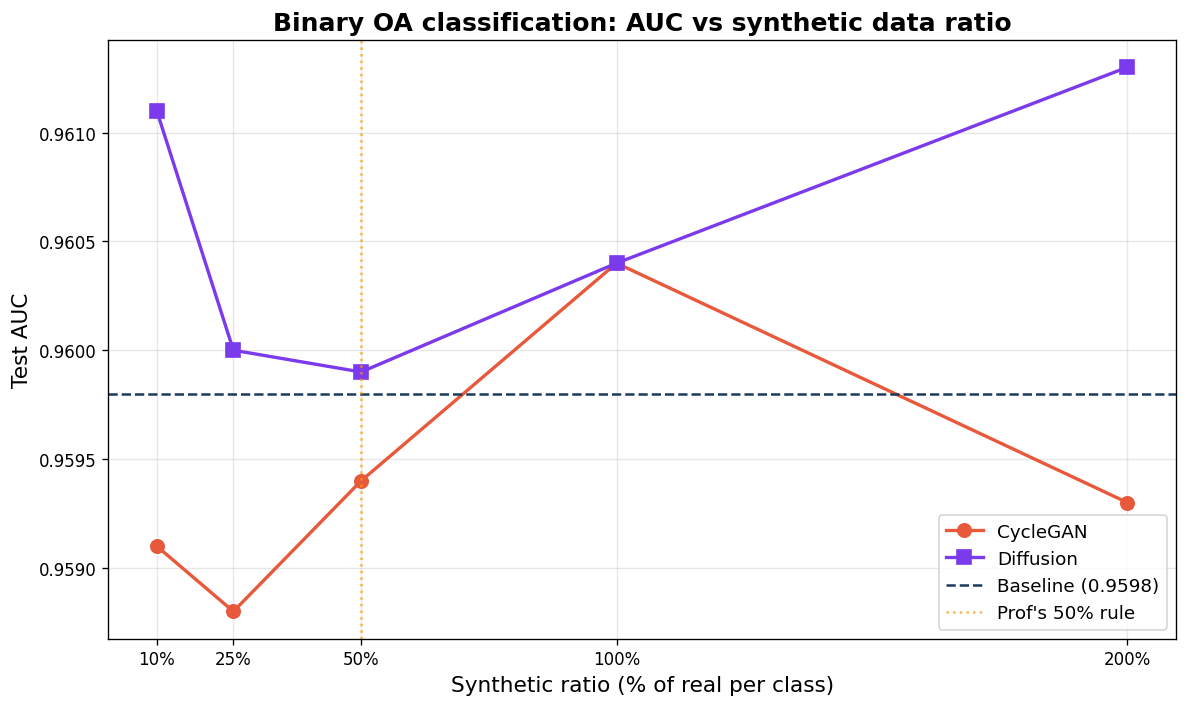

In [ ]:
# ════════════════════════════════════════════════
# Cell 13: Binary results table + plot
# ════════════════════════════════════════════════

print("=" * 70)
print("  BINARY RESULTS: non-OA vs OA")
print("=" * 70)

# Table
print(f"\n{'Config':<30s} {'AUC':>8s} {'± std':>8s} {'Δ baseline':>12s}")
print("-" * 60)

baseline_m, baseline_s = get_auc("baseline_binary")
print(f"{'Baseline (real only)':<30s} {baseline_m:>8.4f} {baseline_s:>8.4f} {'—':>12s}")

ratios_pct = [10, 25, 50, 100, 200]
cycle_aucs, diff_aucs = [], []

for pct in ratios_pct:
    cm, cs = get_auc(f"cycle_binary_{pct}pct")
    dm, ds = get_auc(f"diff_binary_{pct}pct")

    if cm:
        delta_c = cm - baseline_m
        print(f"{'+ CycleGAN ' + str(pct) + '%':<30s} {cm:>8.4f} {cs:>8.4f} {delta_c:>+12.4f}")
        cycle_aucs.append(cm)
    if dm:
        delta_d = dm - baseline_m
        print(f"{'+ Diffusion ' + str(pct) + '%':<30s} {dm:>8.4f} {ds:>8.4f} {delta_d:>+12.4f}")
        diff_aucs.append(dm)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = ratios_pct

if cycle_aucs:
    ax.plot(x, cycle_aucs, 'o-', color='#E8593C', label='CycleGAN', linewidth=2, markersize=8)
if diff_aucs:
    ax.plot(x, diff_aucs, 's-', color='#7C3AED', label='Diffusion', linewidth=2, markersize=8)

ax.axhline(y=baseline_m, color='#1B3A5C', linestyle='--', label=f'Baseline ({baseline_m:.4f})', linewidth=1.5)
ax.axvline(x=50, color='#F59E0B', linestyle=':', alpha=0.7, label="Prof's 50% rule")

ax.set_xlabel('Synthetic ratio (% of real per class)', fontsize=13)
ax.set_ylabel('Test AUC', fontsize=13)
ax.set_title('Binary OA classification: AUC vs synthetic data ratio', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([f'{p}%' for p in x])
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'binary_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()

  5-CLASS RESULTS: KL 0/1/2/3/4

Config                              AUC    ± std   Δ baseline
------------------------------------------------------------
Baseline (real only)             0.8779   0.0148            —
+ Diffusion 10%                  0.8807   0.0098      +0.0028
+ Diffusion 25%                  0.8764   0.0072      -0.0015
+ Diffusion 50%                  0.8860   0.0064      +0.0081
+ Diffusion 100%                 0.8932   0.0131      +0.0153
+ Diffusion 200%                 0.9078   0.0010      +0.0299

Best ratio: 200% — per-class AUC:
  KL 0: baseline=0.936 → +diffusion=0.941 (Δ=+0.005)
  KL 1: baseline=0.784 → +diffusion=0.787 (Δ=+0.003)
  KL 2: baseline=0.921 → +diffusion=0.934 (Δ=+0.013)
  KL 3: baseline=0.939 → +diffusion=0.956 (Δ=+0.018)
  KL 4: baseline=0.892 → +diffusion=0.928 (Δ=+0.036)


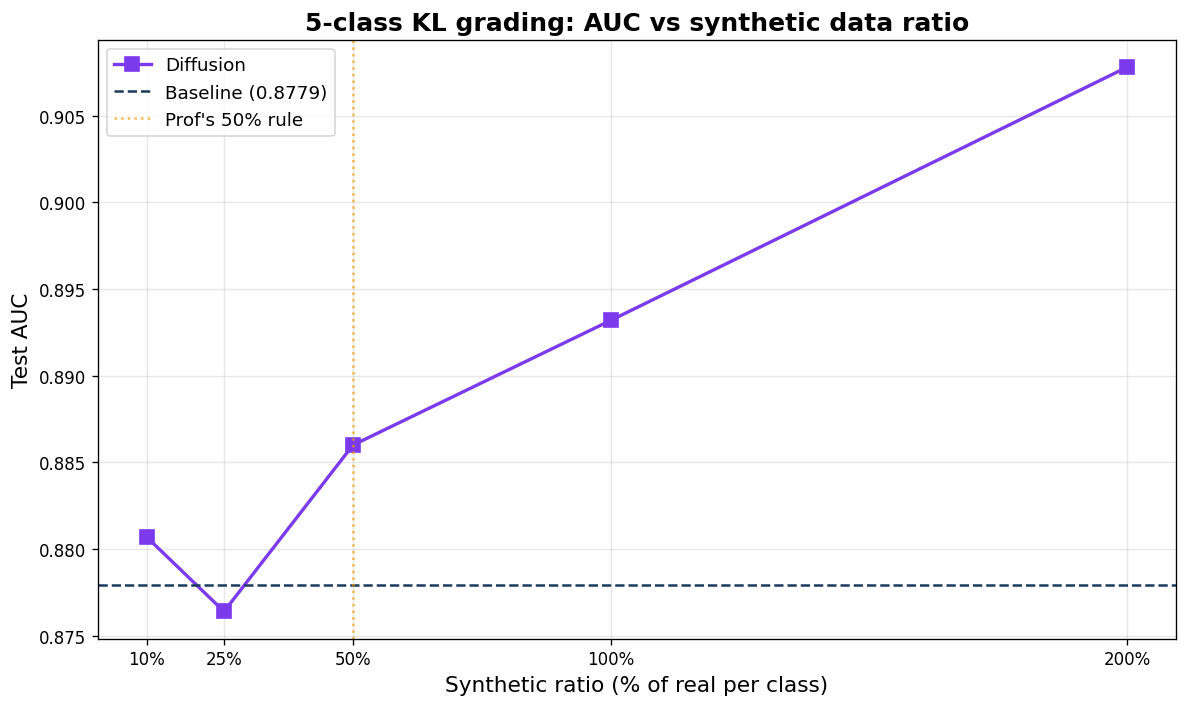

In [ ]:
# ════════════════════════════════════════════════
# Cell 14: 5-class results table + plot
# ════════════════════════════════════════════════

print("=" * 70)
print("  5-CLASS RESULTS: KL 0/1/2/3/4")
print("=" * 70)

baseline_5m, baseline_5s = get_auc("baseline_5class")
print(f"\n{'Config':<30s} {'AUC':>8s} {'± std':>8s} {'Δ baseline':>12s}")
print("-" * 60)
print(f"{'Baseline (real only)':<30s} {baseline_5m:>8.4f} {baseline_5s:>8.4f} {'—':>12s}")

diff_5aucs = []
for pct in ratios_pct:
    dm, ds = get_auc(f"diff_5class_{pct}pct")
    if dm:
        delta = dm - baseline_5m
        print(f"{'+ Diffusion ' + str(pct) + '%':<30s} {dm:>8.4f} {ds:>8.4f} {delta:>+12.4f}")
        diff_5aucs.append(dm)

# Per-class AUC at best ratio
if diff_5aucs:
    best_pct = ratios_pct[np.argmax(diff_5aucs)]
    best_config = f"diff_5class_{best_pct}pct"
    best_run = max(experiment_results[best_config], key=lambda r: r['test_auc'])

    print(f"\nBest ratio: {best_pct}% — per-class AUC:")
    baseline_run = max(experiment_results['baseline_5class'], key=lambda r: r['test_auc'])
    for kl in range(5):
        base_auc = baseline_run.get('per_class_auc', {}).get(kl, 0)
        best_auc = best_run.get('per_class_auc', {}).get(kl, 0)
        delta = best_auc - base_auc if base_auc and best_auc else 0
        print(f"  KL {kl}: baseline={base_auc:.3f} → +diffusion={best_auc:.3f} (Δ={delta:+.3f})")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
if diff_5aucs:
    ax.plot(ratios_pct, diff_5aucs, 's-', color='#7C3AED', label='Diffusion', linewidth=2, markersize=8)
ax.axhline(y=baseline_5m, color='#1B3A5C', linestyle='--', label=f'Baseline ({baseline_5m:.4f})', linewidth=1.5)
ax.axvline(x=50, color='#F59E0B', linestyle=':', alpha=0.7, label="Prof's 50% rule")
ax.set_xlabel('Synthetic ratio (% of real per class)', fontsize=13)
ax.set_ylabel('Test AUC', fontsize=13)
ax.set_title('5-class KL grading: AUC vs synthetic data ratio', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(ratios_pct)
ax.set_xticklabels([f'{p}%' for p in ratios_pct])
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, '5class_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()

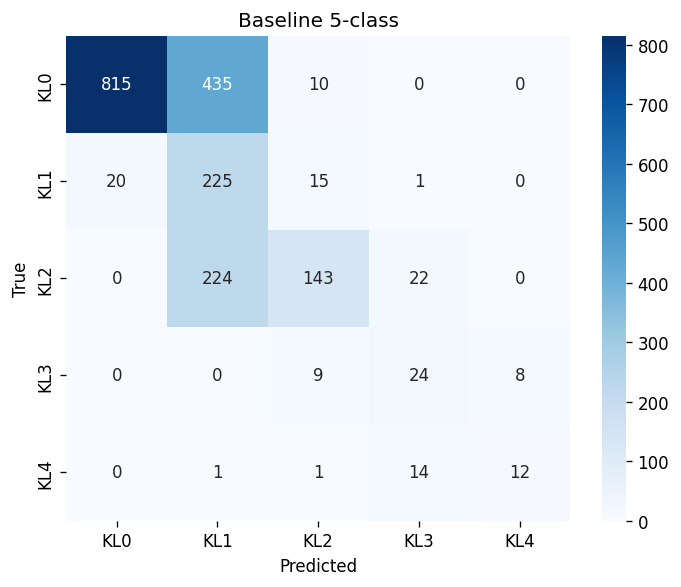

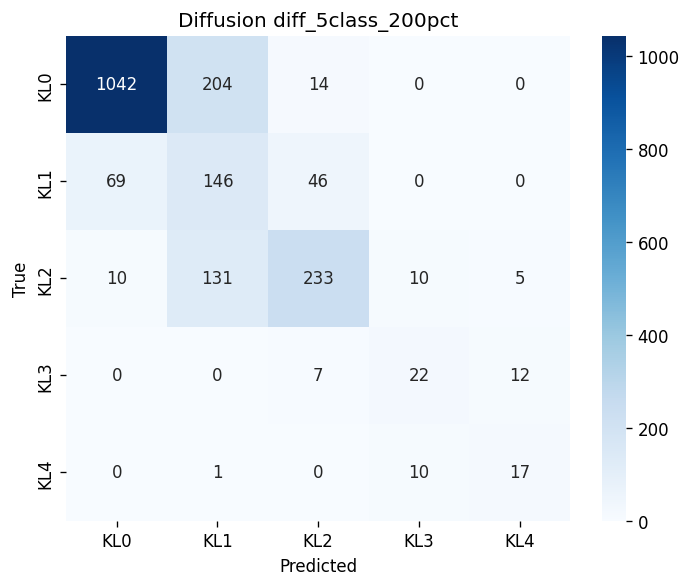

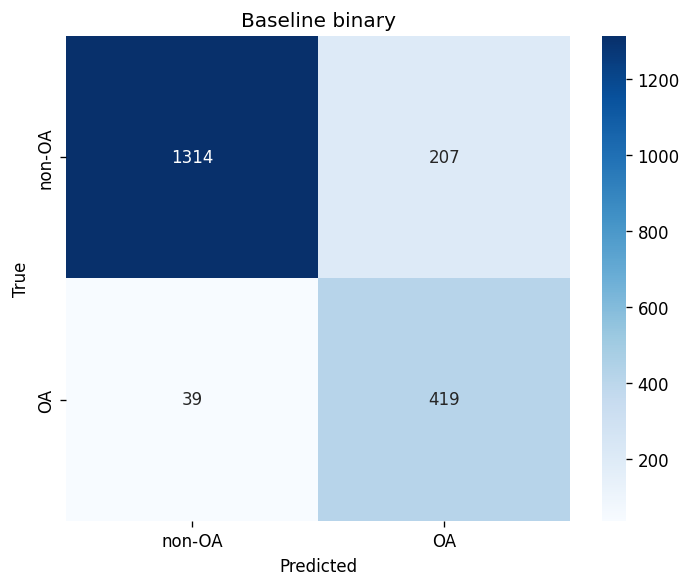

In [ ]:
# ════════════════════════════════════════════════
# Cell 15: Confusion matrices for best configs
# ════════════════════════════════════════════════

def plot_cm(labels, probs, class_names, title):
    preds = probs.argmax(axis=1)
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    return fig

# Baseline 5-class
if 'baseline_5class' in experiment_results:
    best = max(experiment_results['baseline_5class'], key=lambda r: r['test_auc'])
    fig = plot_cm(best['test_labels'], best['test_probs'],
                  ['KL0','KL1','KL2','KL3','KL4'], 'Baseline 5-class')
    fig.savefig(os.path.join(RESULTS_DIR, 'cm_baseline_5class.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Best diffusion 5-class
if diff_5aucs:
    best_config = f"diff_5class_{ratios_pct[np.argmax(diff_5aucs)]}pct"
    best = max(experiment_results[best_config], key=lambda r: r['test_auc'])
    fig = plot_cm(best['test_labels'], best['test_probs'],
                  ['KL0','KL1','KL2','KL3','KL4'], f'Diffusion {best_config}')
    fig.savefig(os.path.join(RESULTS_DIR, f'cm_{best_config}.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Best binary
if 'baseline_binary' in experiment_results:
    best = max(experiment_results['baseline_binary'], key=lambda r: r['test_auc'])
    fig = plot_cm(best['test_labels'], best['test_probs'],
                  ['non-OA','OA'], 'Baseline binary')
    fig.savefig(os.path.join(RESULTS_DIR, 'cm_baseline_binary.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ════════════════════════════════════════════════
# Cell 16: FINAL SUMMARY
# ════════════════════════════════════════════════

print("=" * 70)
print("  FINAL RESULTS SUMMARY")
print("=" * 70)

# FID
print(f"\nDiffusion 180×180 FID per grade:")
for kl, fid in sorted(diff180_fid.items()):
    print(f"  KL {kl}: {fid}")

# Binary
print(f"\nBinary (non-OA vs OA):")
print(f"  Baseline:              {get_auc('baseline_binary')[0]:.4f}")
best_cycle_auc = 0
best_diff_binary_auc = 0
for pct in ratios_pct:
    m, _ = get_auc(f"cycle_binary_{pct}pct")
    if m and m > best_cycle_auc: best_cycle_auc = m
    m, _ = get_auc(f"diff_binary_{pct}pct")
    if m and m > best_diff_binary_auc: best_diff_binary_auc = m
if best_cycle_auc:
    print(f"  Best CycleGAN:         {best_cycle_auc:.4f} (Δ={best_cycle_auc - get_auc('baseline_binary')[0]:+.4f})")
if best_diff_binary_auc:
    print(f"  Best Diffusion:        {best_diff_binary_auc:.4f} (Δ={best_diff_binary_auc - get_auc('baseline_binary')[0]:+.4f})")

# 5-class
print(f"\n5-class (KL 0-4):")
print(f"  Baseline:              {get_auc('baseline_5class')[0]:.4f}")
best_diff_5_auc = 0
for pct in ratios_pct:
    m, _ = get_auc(f"diff_5class_{pct}pct")
    if m and m > best_diff_5_auc: best_diff_5_auc = m
if best_diff_5_auc:
    print(f"  Best Diffusion:        {best_diff_5_auc:.4f} (Δ={best_diff_5_auc - get_auc('baseline_5class')[0]:+.4f})")

# Key findings
print(f"\n{'='*70}")
print("  KEY FINDINGS")
print(f"{'='*70}")

baseline_b = get_auc('baseline_binary')[0]
if best_diff_binary_auc > baseline_b:
    print(f"  ✓ Diffusion improves binary OA detection ({baseline_b:.4f} → {best_diff_binary_auc:.4f})")
else:
    print(f"  ✗ Diffusion did not improve binary OA detection")

if best_cycle_auc and best_diff_binary_auc:
    if best_diff_binary_auc > best_cycle_auc:
        print(f"  ✓ Diffusion > CycleGAN for binary task ({best_diff_binary_auc:.4f} vs {best_cycle_auc:.4f})")
    else:
        print(f"  ~ CycleGAN ≥ Diffusion for binary task")

baseline_5 = get_auc('baseline_5class')[0]
if best_diff_5_auc > baseline_5:
    print(f"  ✓ Diffusion improves 5-class grading ({baseline_5:.4f} → {best_diff_5_auc:.4f})")
else:
    print(f"  ✗ Diffusion did not improve 5-class grading")

print(f"\nAll results saved to: {RESULTS_DIR}/")
for f in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f)) / 1024
    print(f"  {f:45s} {size:.0f} KB")

  FINAL RESULTS SUMMARY

Diffusion 180×180 FID per grade:
  KL 0: 145.53
  KL 1: 145.85
  KL 2: 144.91
  KL 3: 139.57
  KL 4: 152.36

Binary (non-OA vs OA):
  Baseline:              0.9598
  Best CycleGAN:         0.9604 (Δ=+0.0006)
  Best Diffusion:        0.9613 (Δ=+0.0015)

5-class (KL 0-4):
  Baseline:              0.8779
  Best Diffusion:        0.9078 (Δ=+0.0299)

  KEY FINDINGS
  ✓ Diffusion improves binary OA detection (0.9598 → 0.9613)
  ✓ Diffusion > CycleGAN for binary task (0.9613 vs 0.9604)
  ✓ Diffusion improves 5-class grading (0.8779 → 0.9078)

All results saved to: /content/drive/MyDrive/2-Education/0-BU_MSADA/Classes/3-Spring_2026/790_CV/CV-Project/models/eval_results/
  5class_ablation.png                           87 KB
  all_experiment_results.pkl                    2006 KB
  binary_ablation.png                           114 KB
  cm_baseline_5class.png                        43 KB
  cm_baseline_binary.png                        30 KB
  cm_diff_5class_200pct.png    

In [8]:
for config in ['baseline_5class', 'diff_5class_50pct', 'diff_5class_200pct']:
    print(f"\n{config}:")
    for r in experiment_results[config]:
        print(f"  Seed {r['seed']}: AUC={r['test_auc']:.4f}")
        if r.get('per_class_auc'):
            for kl, auc in sorted(r['per_class_auc'].items()):
                print(f"    KL {kl}: {auc:.4f}")


baseline_5class:
  Seed 42: AUC=0.8584
    KL 0: 0.9250
    KL 1: 0.7389
    KL 2: 0.9177
    KL 3: 0.9542
    KL 4: 0.7561
  Seed 123: AUC=0.8809
    KL 0: 0.9384
    KL 1: 0.7500
    KL 2: 0.9072
    KL 3: 0.8884
    KL 4: 0.9204
  Seed 456: AUC=0.8944
    KL 0: 0.9356
    KL 1: 0.7842
    KL 2: 0.9211
    KL 3: 0.9388
    KL 4: 0.8922

diff_5class_50pct:
  Seed 42: AUC=0.8905
    KL 0: 0.9456
    KL 1: 0.7940
    KL 2: 0.9175
    KL 3: 0.9493
    KL 4: 0.8460
  Seed 123: AUC=0.8905
    KL 0: 0.9364
    KL 1: 0.7146
    KL 2: 0.9291
    KL 3: 0.9566
    KL 4: 0.9156
  Seed 456: AUC=0.8769
    KL 0: 0.9259
    KL 1: 0.7589
    KL 2: 0.9135
    KL 3: 0.9653
    KL 4: 0.8211

diff_5class_200pct:
  Seed 42: AUC=0.9071
    KL 0: 0.9393
    KL 1: 0.7764
    KL 2: 0.9214
    KL 3: 0.9755
    KL 4: 0.9229
  Seed 123: AUC=0.9092
    KL 0: 0.9409
    KL 1: 0.7868
    KL 2: 0.9341
    KL 3: 0.9563
    KL 4: 0.9280
  Seed 456: AUC=0.9071
    KL 0: 0.9342
    KL 1: 0.7796
    KL 2: 0.9154
    KL